In [1]:
if (!require(readr)) install.packages("readr")
if (!require(lubridate))install.packages("lubridate")
if (!require(dplyr)) install.packages("dplyr")
if (!require(data.table)) install.packages("data.table")
if (!require(ggplot2)) install.packages("ggplot2")

Загрузка требуемого пакета: readr

Warning message:
"пакет 'readr' был собран под R версии 4.4.3"
Загрузка требуемого пакета: lubridate

Warning message:
"пакет 'lubridate' был собран под R версии 4.4.3"

Присоединяю пакет: 'lubridate'


Следующие объекты скрыты от 'package:base':

    date, intersect, setdiff, union


Загрузка требуемого пакета: dplyr


Присоединяю пакет: 'dplyr'


Следующие объекты скрыты от 'package:stats':

    filter, lag


Следующие объекты скрыты от 'package:base':

    intersect, setdiff, setequal, union


Загрузка требуемого пакета: data.table


Присоединяю пакет: 'data.table'


Следующие объекты скрыты от 'package:dplyr':

    between, first, last


Следующие объекты скрыты от 'package:lubridate':

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Загрузка требуемого пакета: ggplot2

Warning message:
"пакет 'ggplot2' был собран под R версии 4.4.3"


In [2]:
library(readr)
library(lubridate)
library(dplyr)
library(data.table)
library(ggplot2)

## Summary: 
Purpose

Data Sources (events_train, submissions_train)

Metrics for step difficulty

Step-level funnels

Error rates & problematic tasks

A table of the worst performing lessons

Visualizations (heatmaps, barplots, timelines)

Insights for product/design/education team

In [3]:
events_data <- fread("C:/Users/safon/Documents/data_stepic/event_data_train.csv")
submissions_data <- fread("C:/Users/safon/Documents/data_stepic/submissions_data_train.csv")

In [4]:
events_data$timestamp_dt <- as_datetime(events_data$timestamp)
submissions_data$timestamp_dt <- as_datetime(submissions_data$timestamp)

In [5]:
head(events_data)

step_id,timestamp,action,user_id,timestamp_dt
<int>,<int>,<chr>,<int>,<dttm>
32815,1434340848,viewed,17632,2015-06-15 04:00:48
32815,1434340848,passed,17632,2015-06-15 04:00:48
32815,1434340848,discovered,17632,2015-06-15 04:00:48
32811,1434340895,discovered,17632,2015-06-15 04:01:35
32811,1434340895,viewed,17632,2015-06-15 04:01:35
32811,1434340895,passed,17632,2015-06-15 04:01:35


In [6]:
glimpse(events_data)

Rows: 3,480,703
Columns: 5
$ step_id      <int> 32815, 32815, 32815, 32811, 32811, 32811, 32929, 32929, 3…
$ timestamp    <int> 1434340848, 1434340848, 1434340848, 1434340895, 143434089…
$ action       <chr> "viewed", "passed", "discovered", "discovered", "viewed",…
$ user_id      <int> 17632, 17632, 17632, 17632, 17632, 17632, 17632, 17632, 1…
$ timestamp_dt <dttm> 2015-06-15 04:00:48, 2015-06-15 04:00:48, 2015-06-15 04:…


In [7]:
events_data %>%
    summarise(across(everything(),n_distinct))

step_id,timestamp,action,user_id,timestamp_dt
<int>,<int>,<int>,<int>,<int>
198,2196932,4,19234,2196932


In [8]:
summary(events_data)

    step_id         timestamp            action             user_id     
 Min.   : 30456   Min.   :1.434e+09   Length:3480703     Min.   :    1  
 1st Qu.: 32179   1st Qu.:1.450e+09   Class :character   1st Qu.: 6642  
 Median : 32929   Median :1.484e+09   Mode  :character   Median :13208  
 Mean   : 34874   Mean   :1.480e+09                      Mean   :13315  
 3rd Qu.: 33481   3rd Qu.:1.508e+09                      3rd Qu.:20144  
 Max.   :158433   Max.   :1.527e+09                      Max.   :26798  
  timestamp_dt                   
 Min.   :2015-06-15 04:00:48.00  
 1st Qu.:2015-12-16 12:57:45.00  
 Median :2017-01-08 19:25:52.00  
 Mean   :2016-11-27 23:09:31.99  
 3rd Qu.:2017-10-13 10:08:22.00  
 Max.   :2018-05-19 23:33:31.00  

In [9]:
unique(events_data$action)

[1] "viewed"          "passed"          "discovered"      "started_attempt"

In [10]:
events_data %>% count(action) %>% mutate(p = n / sum(n))

action,n,p
<chr>,<int>,<dbl>
discovered,689495,0.19809073
passed,650331,0.18683898
started_attempt,310047,0.08907597
viewed,1830830,0.52599432


In [11]:
colSums(is.na(events_data))

step_id    timestamp       action      user_id timestamp_dt 
           0            0            0            0            0

In [12]:
sum(duplicated(events_data))

[1] 2333

In [13]:
head(submissions_data)

step_id,timestamp,submission_status,user_id,timestamp_dt
<int>,<int>,<chr>,<int>,<dttm>
31971,1434349275,correct,15853,2015-06-15 06:21:15
31972,1434348300,correct,15853,2015-06-15 06:05:00
31972,1478852149,wrong,15853,2016-11-11 08:15:49
31972,1478852164,correct,15853,2016-11-11 08:16:04
31976,1434348123,wrong,15853,2015-06-15 06:02:03
31976,1434348188,correct,15853,2015-06-15 06:03:08


In [14]:
glimpse(submissions_data)

Rows: 509,104
Columns: 5
$ step_id           <int> 31971, 31972, 31972, 31972, 31976, 31976, 31976, 319…
$ timestamp         <int> 1434349275, 1434348300, 1478852149, 1478852164, 1434…
$ submission_status <chr> "correct", "correct", "wrong", "correct", "wrong", "…
$ user_id           <int> 15853, 15853, 15853, 15853, 15853, 15853, 15853, 158…
$ timestamp_dt      <dttm> 2015-06-15 06:21:15, 2015-06-15 06:05:00, 2016-11-1…


In [15]:
submissions_data %>%
    summarise(across(everything(), n_distinct))

step_id,timestamp,submission_status,user_id,timestamp_dt
<int>,<int>,<int>,<int>,<int>
76,504343,2,9940,504343


In [16]:
summary(submissions_data)

    step_id         timestamp         submission_status     user_id     
 Min.   : 31971   Min.   :1.434e+09   Length:509104      Min.   :    2  
 1st Qu.: 32031   1st Qu.:1.450e+09   Class :character   1st Qu.: 6431  
 Median : 32763   Median :1.484e+09   Mode  :character   Median :13082  
 Mean   : 33733   Mean   :1.481e+09                      Mean   :13199  
 3rd Qu.: 33481   3rd Qu.:1.508e+09                      3rd Qu.:19985  
 Max.   :120745   Max.   :1.527e+09                      Max.   :26798  
  timestamp_dt                   
 Min.   :2015-06-15 04:02:24.00  
 1st Qu.:2015-12-12 19:59:30.75  
 Median :2017-01-13 20:16:27.00  
 Mean   :2016-12-01 08:53:27.83  
 3rd Qu.:2017-10-18 11:32:05.25  
 Max.   :2018-05-19 23:07:07.00  

In [17]:
unique(submissions_data$submission_status)

[1] "correct" "wrong"

In [18]:
submissions_data %>% count(submission_status) %>% mutate(p = n / sum(n))

submission_status,n,p
<chr>,<int>,<dbl>
correct,222705,0.437445
wrong,286399,0.562555


In [19]:
colSums(is.na(submissions_data))

step_id         timestamp submission_status           user_id 
                0                 0                 0                 0 
     timestamp_dt 
                0

In [20]:
sum(duplicated(submissions_data))

[1] 107

In [21]:
events_data <- events_data[!duplicated(events_data),]
submissions_data <- submissions_data[!duplicated(submissions_data),]
sum(duplicated(events_data))
sum(duplicated(submissions_data))

[1] 0

[1] 0

In [22]:
user_step_action_count <- events_data[
    , .(n = .N),
    by = .(user_id, step_id, action)
][
    , dcast(.SD, user_id + step_id ~ action, value.var = "n", fill = 0)
]

user_step_action_count[, action_sum := discovered + passed + started_attempt + viewed]

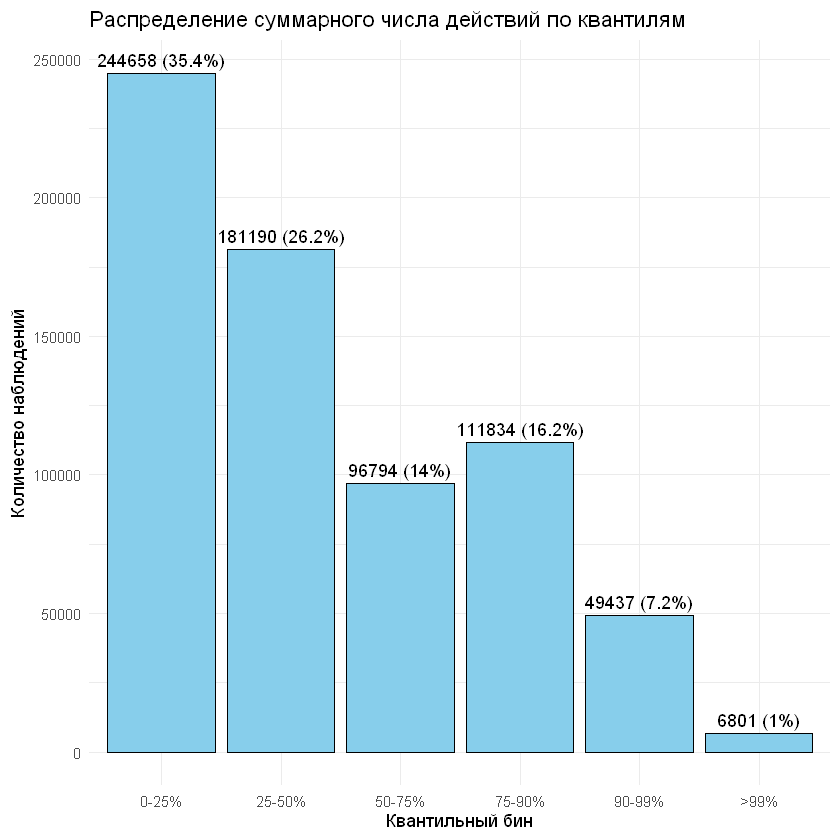

In [23]:
library(data.table)
library(ggplot2)

# 1. Создаем таблицу с подсчетом количества действий по user_id и step_id
user_step_action_count <- events_data[
    , .(n = .N), 
    by = .(user_id, step_id, action)
][
    , dcast(.SD, user_id + step_id ~ action, value.var = "n", fill = 0)
]

# 2. Суммируем все действия
user_step_action_count[, action_sum := discovered + passed + started_attempt + viewed]

# 3. Преобразуем в числовую (на всякий случай)
user_step_action_count[, sum_numeric := as.numeric(action_sum)]

# 4. Вычисляем квантильные пороги
quantiles <- quantile(user_step_action_count$sum_numeric, probs = c(0, 0.25, 0.5, 0.75, 0.9, 0.99, 1))

# 5. Создаем бины по квантилям
user_step_action_count[, sum_bin := cut(
  sum_numeric,
  breaks = quantiles,
  include.lowest = TRUE,
  labels = c("0-25%", "25-50%", "50-75%", "75-90%", "90-99%", ">99%")
)]

# 6. Считаем количество наблюдений и процент по бинам
bin_counts <- user_step_action_count[, .N, by = sum_bin]
bin_counts[, perc := round(100 * N / sum(N), 1)]

# 7. Визуализация
ggplot(bin_counts, aes(x = sum_bin, y = N)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black") +
  geom_text(aes(label = paste0(N, " (", perc, "%)")), vjust = -0.5) +
  labs(
    title = "Распределение суммарного числа действий по квантилям",
    x = "Квантильный бин",
    y = "Количество наблюдений"
  ) +
  theme_minimal()


In [24]:
user_step_action_count %>%
  group_by(sum_bin) %>%
  summarise(
    min_sum = min(action_sum),
    max_sum = max(action_sum),
    unique_users = n_distinct(user_id), 
    .groups = "drop"
  )
   

sum_bin,min_sum,max_sum,unique_users
<fct>,<int>,<int>,<int>
0-25%,1,3,18189
25-50%,4,4,11605
50-75%,5,5,9074
75-90%,6,8,8025
90-99%,9,18,5397
>99%,19,576,1682
